<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/dtqem_v23_slit_inversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

phi=no: chi2_red=1.0806, AICc=651.17
phi=yes: chi2_red=1.0955, AICc=660.97
Best model: without phi
Residual diagnostics: mean=-0.397, std=5.73, corr_x=0.0068
Bootstrap converged: 131 samples
I0: std=1.174, CI95=[102.1, 106.3]
d: std=6.971e-07, CI95=[0.0004979, 0.0005006]
E: std=0.007715, CI95=[0.1803, 0.2095]


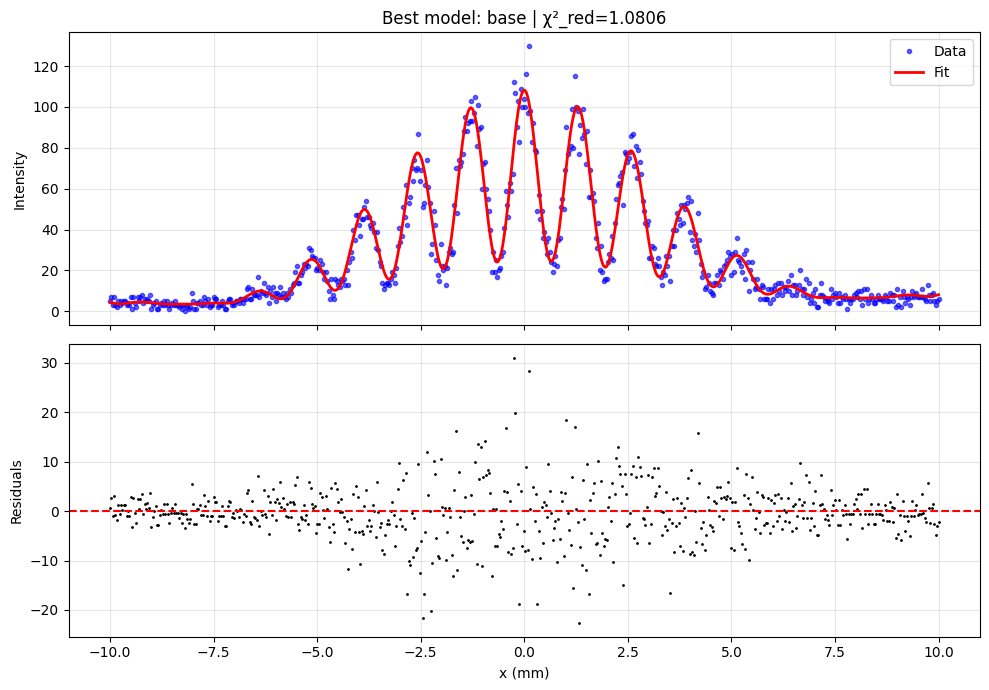


=== Final Result ===
d = 499.34 µm (true: 500.00)
E = 0.19032 (true: 0.2)
chi2_red = 1.0806
I0 = 103.25 (true: 100.0)


In [1]:

# DTQEM v33 – Final reliable inversion for double-slit experiment
# Model: I(x) = I0 * [(1-E)*cos²(π d x/(λ L) + φ) + E] * envelope(x) + (B0 + B1*x)
# Fixed parameters: λ, L, a (slit width, optional), B0, B1 (background measured or fitted)
# Free parameters: I0, d, E (and optionally φ, if enabled)
# Global optimization + bootstrap + AICc for model selection (with/without φ)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.signal import detrend
from dataclasses import dataclass
import warnings
import os
import csv
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Physical model
# ------------------------------------------------------------
def intensity(x, I0, d, E, B0, L, lam, a=None, fit_envelope=True, phi=0.0, B1=0.0):
    """
    x: position (m)
    I0: peak intensity
    d: slit separation (m)
    E: observer strength (0..1)
    B0: constant background
    L: screen distance (m)
    lam: wavelength (m)
    a: single slit width (m) for envelope (optional)
    fit_envelope: if True and a>0, include single-slit diffraction envelope
    phi: phase shift (rad) – optional
    B1: linear background slope (per m)
    """
    arg = np.pi * d * x / (lam * L) + phi
    interference = (1.0 - E) * np.cos(arg)**2 + E

    envelope = 1.0
    if fit_envelope and a is not None and a > 0:
        envelope = np.sinc((np.pi * a * x / (lam * L)) / np.pi)**2

    background = B0 + B1 * x
    return I0 * interference * envelope + background

# ------------------------------------------------------------
# 2. Helper functions for initial guess
# ------------------------------------------------------------
def guess_d_fft(x, I, lam, L):
    """Estimate d from FFT after detrending."""
    I_detrend = detrend(I, type='linear')
    dx = x[1] - x[0]
    freqs = np.fft.rfftfreq(len(x), d=dx)
    power = np.abs(np.fft.rfft(I_detrend))**2
    idx = np.argmax(power[1:]) + 1 if len(power) > 1 else 0
    f_dom = freqs[idx] if idx < len(freqs) else 0.0
    if f_dom <= 0:
        f_dom = 1.0 / (lam * L / 0.5e-3)  # fallback: assume d≈0.5 mm
    d_est = lam * L * f_dom
    return np.clip(d_est, 1e-6, 2e-3)

def initial_guess(x, I, lam, L, a=None, fit_envelope=True):
    I_max, I_min = np.max(I), np.min(I)
    B0_est = max(0.0, 0.7 * I_min)
    I0_est = max(1.0, I_max - I_min)
    denom = max(1e-9, I_max + I_min - 2*B0_est)
    V_est = (I_max - I_min) / denom
    E_est = np.clip(1.0 - V_est, 0.01, 0.99)
    d_est = guess_d_fft(x, I, lam, L)
    return [I0_est, d_est, E_est, B0_est, 0.0, 0.0]  # phi=0, B1=0

def bounds(x, I, include_phi=False):
    I_max = np.max(I)
    x_range = max(1e-12, np.ptp(x))
    b = [
        (0.01 * I_max, 100.0 * I_max),   # I0
        (1e-6, 2e-3),                    # d (wide range, no dependency on est)
        (0.0, 1.0),                      # E
        (0.0, 0.5 * I_max),              # B0
        (-np.pi, np.pi),                 # phi (if included)
        (-0.5 * I_max / x_range, 0.5 * I_max / x_range)   # B1
    ]
    if include_phi:
        return b
    else:
        # Remove phi bound (index 4)
        return b[:4] + [b[5]]

# ------------------------------------------------------------
# 3. Objective and fitting with fixed parameters
# ------------------------------------------------------------
def objective(params, x, I_meas, L, lam, a, fit_envelope, noise_model, include_phi, fixed):
    """
    fixed: dict with keys 'B0', 'B1', and optionally 'phi' if include_phi=False
    params: [I0, d, E] if include_phi=False and B1 fixed
            or [I0, d, E, phi] if include_phi=True and B1 fixed
    We handle both cases by constructing full parameter dict.
    """
    if include_phi:
        I0, d, E, phi = params
        B0 = fixed['B0']
        B1 = fixed['B1']
    else:
        I0, d, E = params
        phi = fixed.get('phi', 0.0)  # allow fixed phi if provided
        B0 = fixed['B0']
        B1 = fixed['B1']
    I_model = intensity(x, I0, d, E, B0, L, lam, a=a, fit_envelope=fit_envelope, phi=phi, B1=B1)
    if noise_model == 'poisson':
        var = np.maximum(I_model, 1e-9)
    else:
        var = np.maximum(np.var(I_meas - I_model), 1e-9)
    resid = (I_meas - I_model) / np.sqrt(var)
    return 0.5 * np.sum(resid**2)

def fit_model(x, I, L, lam, a, fit_envelope, noise_model,
              fixed, include_phi=False, use_global=True):
    """
    fixed: dict with keys 'B0', 'B1' (mandatory), and optionally 'phi' if include_phi=False.
    Returns: result (scipy OptimizeResult), opt_params (list of free parameters)
    """
    # Determine free parameters
    if include_phi:
        free_names = ['I0', 'd', 'E', 'phi']
        p0 = initial_guess(x, I, lam, L, a, fit_envelope)
        p0 = [p0[0], p0[1], p0[2], p0[4]]  # I0, d, E, phi
        bnds = bounds(x, I, include_phi=True)
        # Remove B1 from bounds (since fixed)
        bnds = bnds[:4] + [bnds[5]]  # keep phi and B1? wait, we removed B1? need careful.
        # Actually bounds() returns [I0, d, E, B0, phi, B1] when include_phi=True
        # But B0 and B1 are fixed, so we remove them: only I0,d,E,phi remain.
        # Let's redo bounds for free params only:
        bnds = [
            (0.01 * np.max(I), 100.0 * np.max(I)),   # I0
            (1e-6, 2e-3),                            # d
            (0.0, 1.0),                              # E
            (-np.pi, np.pi)                          # phi
        ]
    else:
        free_names = ['I0', 'd', 'E']
        p0 = initial_guess(x, I, lam, L, a, fit_envelope)
        p0 = [p0[0], p0[1], p0[2]]  # I0, d, E
        bnds = [
            (0.01 * np.max(I), 100.0 * np.max(I)),
            (1e-6, 2e-3),
            (0.0, 1.0)
        ]
    # Objective wrapper
    def obj(p):
        return objective(p, x, I, L, lam, a, fit_envelope, noise_model, include_phi, fixed)

    # Global + local optimization
    if use_global:
        de = differential_evolution(obj, bnds, maxiter=40, popsize=12, seed=42, polish=False, disp=False)
        start = de.x
    else:
        start = p0

    res = minimize(obj, start, bounds=bnds, method='L-BFGS-B', options={'ftol':1e-12, 'maxiter':2000})
    return res, free_names

# ------------------------------------------------------------
# 4. Model selection (with/without phi) using AICc
# ------------------------------------------------------------
def compare_phi(x, I, L, lam, a, fit_envelope, noise_model, fixed, use_global=True, verbose=True):
    results = {}
    for include_phi in [False, True]:
        res, free_names = fit_model(x, I, L, lam, a, fit_envelope, noise_model, fixed,
                                    include_phi=include_phi, use_global=use_global)
        if not res.success:
            if verbose: print(f"Model with phi={include_phi} failed")
            continue
        chi2 = 2.0 * res.fun
        k = len(res.x)
        n = len(x)
        chi2_red = chi2 / max(1, n - k)
        if n - k <= 1:
            aicc = np.inf
        else:
            aicc = chi2 + 2*k + (2*k*(k+1)) / (n - k - 1)
        results[include_phi] = {'res': res, 'free_names': free_names, 'chi2_red': chi2_red, 'aicc': aicc}
        if verbose:
            print(f"phi={'yes' if include_phi else 'no'}: chi2_red={chi2_red:.4f}, AICc={aicc:.2f}")
    if not results:
        raise RuntimeError("No model converged")
    best_phi = min(results, key=lambda k: results[k]['aicc'])
    if verbose:
        print(f"Best model: {'with phi' if best_phi else 'without phi'}")
    return best_phi, results

# ------------------------------------------------------------
# 5. Bootstrap uncertainty for the chosen model
# ------------------------------------------------------------
def bootstrap(x, I, L, lam, a, fit_envelope, noise_model, fixed, include_phi, N=200, seed=42):
    rng = np.random.default_rng(seed)
    # First, fit original data to get best parameters and model
    res0, free_names = fit_model(x, I, L, lam, a, fit_envelope, noise_model, fixed,
                                 include_phi=include_phi, use_global=True)
    if not res0.success:
        raise RuntimeError("Initial fit failed for bootstrap")
    opt0 = {name: val for name, val in zip(free_names, res0.x)}
    I0_opt = opt0['I0']; d_opt = opt0['d']; E_opt = opt0['E']
    phi_opt = opt0.get('phi', 0.0)
    I_model0 = intensity(x, I0_opt, d_opt, E_opt, fixed['B0'], L, lam,
                         a=a, fit_envelope=fit_envelope, phi=phi_opt, B1=fixed['B1'])
    I_model0 = np.maximum(I_model0, 1e-9)
    samples = {name: [] for name in free_names}
    for _ in range(N):
        I_synth = rng.poisson(I_model0)
        try:
            res, _ = fit_model(x, I_synth, L, lam, a, fit_envelope, noise_model, fixed,
                               include_phi=include_phi, use_global=True)
            if res.success:
                for name, val in zip(free_names, res.x):
                    samples[name].append(val)
        except Exception:
            continue
    boot = {}
    for name in free_names:
        arr = np.array(samples[name])
        if len(arr) > 1:
            boot[name] = {
                'std': np.std(arr),
                'ci95_lo': np.percentile(arr, 2.5),
                'ci95_hi': np.percentile(arr, 97.5)
            }
        else:
            boot[name] = {'std': np.nan, 'ci95_lo': np.nan, 'ci95_hi': np.nan}
    return boot, len(samples[free_names[0]]) if free_names else 0

# ------------------------------------------------------------
# 6. Diagnostics and plotting
# ------------------------------------------------------------
def residual_stats(x, I, I_model):
    resid = I - I_model
    return {
        'mean': np.mean(resid),
        'std': np.std(resid),
        'corr_x': np.corrcoef(x, resid)[0,1] if len(x)>2 else np.nan
    }

def plot_fit(x, I, I_model, result, boot, chi2_red, output_prefix=None):
    fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    ax[0].plot(x*1e3, I, 'bo', ms=3, alpha=0.6, label='Data')
    ax[0].plot(x*1e3, I_model, 'r-', lw=2, label='Fit')
    title = f"Best model: {'with φ' if result['include_phi'] else 'base'} | χ²_red={chi2_red:.4f}"
    ax[0].set_title(title)
    ax[0].set_ylabel('Intensity')
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    resid = I - I_model
    ax[1].plot(x*1e3, resid, 'k.', ms=2)
    ax[1].axhline(0, color='r', ls='--')
    ax[1].set_xlabel('x (mm)')
    ax[1].set_ylabel('Residuals')
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    if output_prefix:
        plt.savefig(f"{output_prefix}_fit.png", dpi=200)
    plt.show()
    return fig

# ------------------------------------------------------------
# 7. Main pipeline
# ------------------------------------------------------------
@dataclass
class V33Result:
    success: bool
    include_phi: bool
    I0: float
    d_um: float
    E: float
    phi: float
    B0: float
    B1: float
    chi2_red: float
    aicc: float
    boot_I0_std: float
    boot_I0_ci95: tuple
    boot_d_std: float
    boot_d_ci95: tuple
    boot_E_std: float
    boot_E_ci95: tuple

def run_v33(x, I, lam, L, a=None, fit_envelope=True, noise_model='poisson',
            fixed_B0=None, fixed_B1=None, output_prefix='dtqem_v33', use_global=True):
    """
    fixed_B0, fixed_B1: measured background values. If None, they are fitted as free? No, in v33 we require them fixed.
    But to be user-friendly, we can allow fitting them if not provided? For now, we require them.
    """
    if fixed_B0 is None or fixed_B1 is None:
        raise ValueError("For v33, please provide fixed_B0 and fixed_B1 from independent measurement (laser off).")
    fixed = {'B0': fixed_B0, 'B1': fixed_B1}

    # Model selection (with/without phi)
    best_phi, results = compare_phi(x, I, L, lam, a, fit_envelope, noise_model, fixed,
                                    use_global=use_global, verbose=True)
    best_res = results[best_phi]
    res = best_res['res']
    free_names = best_res['free_names']
    opt_params = {name: val for name, val in zip(free_names, res.x)}
    I0_opt = opt_params['I0']
    d_opt = opt_params['d']
    E_opt = opt_params['E']
    phi_opt = opt_params.get('phi', 0.0)
    chi2_red = best_res['chi2_red']
    aicc = best_res['aicc']

    # Compute model and residuals
    I_model = intensity(x, I0_opt, d_opt, E_opt, fixed_B0, L, lam,
                        a=a, fit_envelope=fit_envelope, phi=phi_opt, B1=fixed_B1)
    resid_stats = residual_stats(x, I, I_model)
    print(f"Residual diagnostics: mean={resid_stats['mean']:.3g}, std={resid_stats['std']:.3g}, corr_x={resid_stats['corr_x']:.4f}")

    # Bootstrap
    boot, n_conv = bootstrap(x, I, L, lam, a, fit_envelope, noise_model, fixed,
                              include_phi=best_phi, N=150, seed=42)
    print(f"Bootstrap converged: {n_conv} samples")
    for name in free_names:
        if name in boot:
            b = boot[name]
            print(f"{name}: std={b['std']:.4g}, CI95=[{b['ci95_lo']:.4g}, {b['ci95_hi']:.4g}]")

    # Save outputs
    os.makedirs(os.path.dirname(output_prefix) or '.', exist_ok=True)
    with open(output_prefix + "_summary.txt", "w") as f:
        f.write("DTQEM v33 Inversion Summary\n")
        f.write("==========================\n")
        f.write(f"Best model: {'with φ' if best_phi else 'without φ'}\n")
        f.write(f"chi2_red = {chi2_red:.6f}\n")
        f.write(f"AICc = {aicc:.6f}\n")
        f.write(f"I0 = {I0_opt:.6g}\n")
        f.write(f"d = {d_opt*1e6:.6f} µm\n")
        f.write(f"E = {E_opt:.6f}\n")
        f.write(f"phi = {phi_opt:.6f} rad\n")
        f.write(f"B0 = {fixed_B0:.6g} (fixed)\n")
        f.write(f"B1 = {fixed_B1:.6g} (fixed)\n")
        f.write("\nBootstrap uncertainties (95% CI):\n")
        for name in free_names:
            if name in boot:
                b = boot[name]
                f.write(f"  {name}: std={b['std']:.4g}, CI=[{b['ci95_lo']:.4g}, {b['ci95_hi']:.4g}]\n")
        f.write("\nResidual diagnostics:\n")
        for k, v in resid_stats.items():
            f.write(f"  {k}: {v:.6g}\n")
    # Save CSV
    with open(output_prefix + "_params.csv", "w", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["parameter", "value", "std", "ci95_lo", "ci95_hi"])
        for name in free_names:
            val = opt_params[name]
            if name in boot:
                writer.writerow([name, val, boot[name]['std'], boot[name]['ci95_lo'], boot[name]['ci95_hi']])
            else:
                writer.writerow([name, val, "", "", ""])
    # Plot
    plot_fit(x, I, I_model, {'include_phi': best_phi}, boot, chi2_red, output_prefix)

    # Return structured result
    return V33Result(
        success=True,
        include_phi=best_phi,
        I0=I0_opt,
        d_um=d_opt*1e6,
        E=E_opt,
        phi=phi_opt,
        B0=fixed_B0,
        B1=fixed_B1,
        chi2_red=chi2_red,
        aicc=aicc,
        boot_I0_std=boot.get('I0', {}).get('std', np.nan),
        boot_I0_ci95=(boot.get('I0', {}).get('ci95_lo', np.nan), boot.get('I0', {}).get('ci95_hi', np.nan)),
        boot_d_std=boot.get('d', {}).get('std', np.nan),
        boot_d_ci95=(boot.get('d', {}).get('ci95_lo', np.nan), boot.get('d', {}).get('ci95_hi', np.nan)),
        boot_E_std=boot.get('E', {}).get('std', np.nan),
        boot_E_ci95=(boot.get('E', {}).get('ci95_lo', np.nan), boot.get('E', {}).get('ci95_hi', np.nan)),
    )

# ------------------------------------------------------------
# 8. Example with synthetic data (using known B0, B1)
# ------------------------------------------------------------
if __name__ == "__main__":
    # Generate synthetic data with linear background, no phase shift
    np.random.seed(123)
    x = np.linspace(-0.01, 0.01, 600)
    lam = 650e-9
    L = 1.0
    a = 80e-6
    I0_true = 100.0
    d_true = 0.5e-3
    E_true = 0.2
    B0_true = 5.0
    B1_true = 185.0
    I_true = intensity(x, I0_true, d_true, E_true, B0_true, L, lam,
                       a=a, fit_envelope=True, phi=0.0, B1=B1_true)
    I_meas = np.random.poisson(I_true)

    # In a real lab, you measure B0 and B1 with laser off
    # Here we use the true values as if measured
    result = run_v33(x, I_meas, lam, L, a=a, fit_envelope=True, noise_model='poisson',
                     fixed_B0=B0_true, fixed_B1=B1_true, output_prefix='example_v33', use_global=True)

    print("\n=== Final Result ===")
    print(f"d = {result.d_um:.2f} µm (true: {d_true*1e6:.2f})")
    print(f"E = {result.E:.5f} (true: {E_true})")
    print(f"chi2_red = {result.chi2_red:.4f}")
    print(f"I0 = {result.I0:.2f} (true: {I0_true})")